# **Auto-Labeling Pipeline with SAM3**

The main objective of this notebook is to build a `python` script to *automate* the hardest and most tedious part of a *Machine Learning* project that is the annotation of the `GROUND_TRUTH` of our *datasets*.

Therefore, since our end objective of this step of the this project is made a *fine-tuning* of a **YOLO** model for the task of *Argentinian ID Card* detection. We will use this *pre-labeling* pipeline to assign the respective labels to our samples.

To this job of *pre-labeling* we will use **SAM3** *(Segment Anything Model)* from **Meta** *(Facebook)* such as the base model for segmenting our samples into our different *classes*, and generate the *annotated files* in **YOLO** OBB *(Oriented Bounding Boxes)* format in an automate way.

## **Pipeline Steps:**

* Define settings variables and **SAM3** model input parameters.
* Read all samples from `input directory`.
* Create a global instance of **SAM3** model using the *API* provides by **Ultralytics**.
* Make the inference for each sample.
* From the mask obtained through the inference, extract the 4 corners of the object.
* Normalize the `xy` coordinates of each corner.
* Save annotated file with its respectives annotations with the follow format:
  * `cls x1 y1 x2 y2 x3 y3 x4 y4`

## **Expected Input:**

* `directory` that contains all not labeling samples.

## **Expected Output:**

* `label directory` that containing the annotation files for each sample.


### **Inference Example**
<table>
  <tr>
    <td align="center" style="padding: 10px;">
      <img src="./assets/example1.png" width="420"><br>
      <em>Figure 1. Result of SAM3 inference.</em>
    </td>
    <td align="center" style="padding: 10px;">
      <img src="./assets/example2.png" width="420"><br>
      <em>Figura 2. Result of Oriented Bounding Boxes.</em>
    </td>
  </tr>
</table>

## **Libraries and Constants**

In [1]:
from ultralytics.models.sam import SAM3SemanticPredictor
from ultralytics.engine.results import Results, Masks, Boxes
from typing import List
from tqdm import tqdm
import ultralytics
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import logging
import warnings
import torch

warnings.filterwarnings("ignore")
logging.getLogger("ultralytics").setLevel(logging.ERROR)

if not os.environ.get("BASE_PROJECT_DIR"):
    os.environ["BASE_PROJECT_DIR"] = input("Enter the base project directory path: ")

INPUT_NOT_LABELLING_DIR = os.getenv("BASE_PROJECT_DIR") + "/data/prc/input/"
SAMPLES = os.listdir(INPUT_NOT_LABELLING_DIR + "images/")
SHOW_PLOTS = False  # Set to True to display plots during processing

# SAM3 model parameters
CONF = 0.25
TASK = "segment"
MODE = "predict"
CLASSES = ["front card", "back card"]
FRONT_ID = 0
BACK_ID = 1

print(f"Numpy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Ultralytics version: {ultralytics.__version__}")
print(f"PyTorch version: {torch.__version__}")

Numpy version: 2.3.5
OpenCV version: 4.10.0
Matplotlib version: 3.11.0
Ultralytics version: 8.4.117
PyTorch version: 2.13.0+cu130


* Define some necessary functions to execute the pipeline for the follow tasks:
  * Load an image.
  * Make an inference with **SAM3**.
  * Extract the corner OBB from the mask.
  * Normalize the coordinates of eache corner.
  * Annotate the sample.
* Also define functions to show images.

In [2]:
def load_image(image_path):
    """Load an image from the specified path."""
    return cv2.imread(image_path)

def predict(predictor: SAM3SemanticPredictor, 
            image_path: str,
            classes: List[str]) -> Results:
    """Run prediction on the given image using the provided predictor."""
    predictor.set_image(image_path)

    # Query with multiple text prompts
    result = predictor(text=classes)[0]
    return result

def extract_obb_from_mask(masks: Masks) -> List:
    """Extract the oriented bounding box (OBB) from the detected masks."""
    obbs = []
    if masks is None or len(masks.xy) == 0:
        return obbs  # Return empty list if no masks are detected
    for mask in masks.xy:
        # Extract the contour points from the mask
        contour = mask 

        # Calculate the minimum area rotated rectangle
        rect = cv2.minAreaRect(contour.astype(np.float32))

        # Get the 4 corners (x1,y1), (x2,y2), (x3,y3), (x4,y4)
        box = cv2.boxPoints(rect)
        box = order_corners_atan2(box)   # orden consistente para cualquier ángulo

        obbs.append(box)
    return obbs

def order_corners_atan2(box: np.ndarray) -> np.ndarray:
    """Order 4 corners consistently (clockwise) for any rotation.

    Args:
        box (np.ndarray): shape (4, 2).

    Returns:
        np.ndarray: corners ordered clockwise starting from top-most point.
    """
    box = box.astype(np.float32)
    center = box.mean(axis=0)

    # Ángulo polar de cada esquina respecto al centro
    angles = np.arctan2(box[:, 1] - center[1], box[:, 0] - center[0])

    # Orden circular (horario en coordenadas de imagen: y hacia abajo)
    order = np.argsort(angles)
    ordered = box[order]

    # Punto de arranque fijo: el de menor y (desempate: menor x)
    start = np.lexsort((ordered[:, 0], ordered[:, 1]))[0]
    ordered = np.roll(ordered, -start, axis=0)

    return np.int32(ordered)

def normalize_coord(coord, width, height):
    """Normalize the coordinates to be in the range [0, 1]."""
    x, y = coord
    return [x / width, y / height]

def annotate_yolo_obb_format(img: str,
                             obbs: List[np.ndarray],
                             boxes: List[Boxes],
                             output_label_path: str) -> bool:
    """Annotate the image with OBBs in YOLO format and save the annotated image."""
    img = load_image(img)
    classes = boxes.cls.tolist()  # Get the class indices for each box
    try:
        with open(output_label_path, "w") as f:
            for box, cls in zip(obbs, classes):
                # clase x1 y1 x2 y2 x3 y3 x4 y4
                box = [normalize_coord(coord, img.shape[1], img.shape[0]) for coord in box]
                label = f"{int(cls)} " + " ".join([f"{coord}" for point in box for coord in point])
                f.write(label + "\n")

        return True
    except Exception as e:
        print(f"Error annotating YOLO OBB format: {e}")
        return False

def draw_obb_on_image(image_path: str, obbs: List[np.ndarray]) -> np.ndarray:
    """Draw the OBB on the image and return the annotated image."""
    img = load_image(image_path)

    for box in obbs:
        # Reorganize the array to the structure required by cv2.polylines: (1, 4, 2)
        pts = box.reshape((-1, 1, 2))

        # Draw the OBB on the image
        cv2.polylines(img, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

    return img

def show_image(image: np.ndarray, title: str = "Image"):
    """Display the image using matplotlib."""
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

def plot_images(images: list, labels: list):
    # Create subplots
    fig, ax = plt.subplots(1, len(images), figsize=(10, 5))

    for index, img in enumerate(images):
        # Show each image in subplot
        ax[index].imshow(img)
        ax[index].set_title(labels[index])
        ax[index].axis('off')

        fig.tight_layout()
    plt.show()

* Initialize **SAM3** model with a custom configuration.

In [ ]:
# Initialize SAM3 model with configuration
overrides = {
    "conf": CONF,
    "task": TASK,
    "mode": MODE,
    "model": f"{os.getenv("BASE_PROJECT_DIR", "")}/weigths/sam/sam3.pt",
    "quantize": 16,  # Use FP16 for faster inference
    "save": False,
    "verbose": False,
}

predictor = SAM3SemanticPredictor(overrides=overrides)
predictor

### **SAM3 inference example for one SAMPLE**

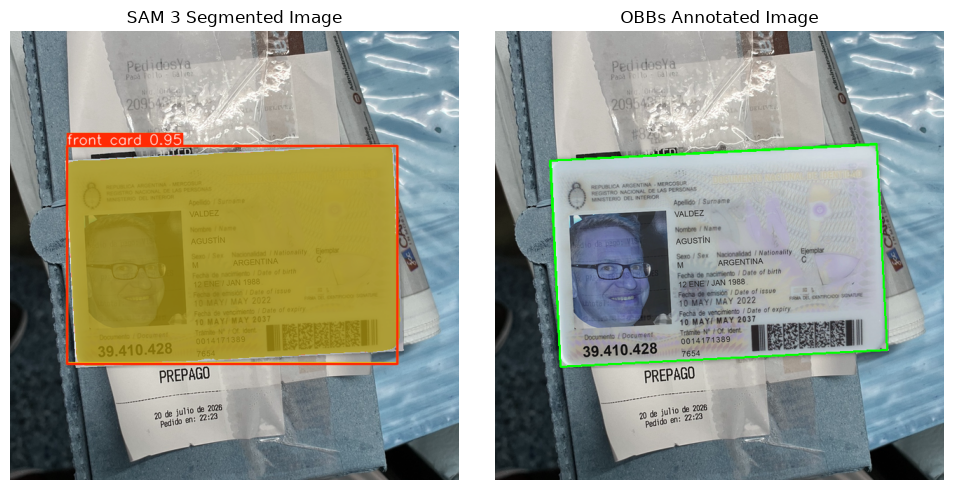

In [4]:
result = predict(predictor=predictor,
                 image_path=os.path.join(INPUT_NOT_LABELLING_DIR, "images", SAMPLES[0]),
                 classes=CLASSES)
obbs = extract_obb_from_mask(masks=result.masks)
img = draw_obb_on_image(image_path=os.path.join(INPUT_NOT_LABELLING_DIR, "images", SAMPLES[0]),
                        obbs=obbs)
plot_images(images=[result.plot(), img],
            labels=["SAM 3 Segmented Image", "OBBs Annotated Image"])

## **Execute the pre-labeling process**

Now execute this pipeline for all our samples.

In [6]:
SAMPLES = [os.path.join(INPUT_NOT_LABELLING_DIR, "images", sample) for sample in SAMPLES]
print(f"Total samples to annotate: {len(SAMPLES)}")
# SAMPLES = SAMPLES[:10]  # Limit to first 10 samples for testing
# SAMPLES

Total samples to annotate: 880


In [7]:
for sample in tqdm(SAMPLES, desc="Automate Labeling with SAM3"):
    result = predict(predictor=predictor,
                     image_path=sample,
                     classes=CLASSES)
    obbs = extract_obb_from_mask(masks=result.masks)
    out_label_path = os.path.join(INPUT_NOT_LABELLING_DIR, "labels",
                                   os.path.basename(sample)
                                   .replace(".jpg", ".txt")
                                   .replace(".png", ".txt"))
    annotate_yolo_obb_format(img=sample,
                             obbs=obbs,
                             boxes=result.boxes,
                             output_label_path=out_label_path)
    if SHOW_PLOTS:
        img = draw_obb_on_image(image_path=sample, obbs=obbs)
        plot_images(images=[result.plot(), img],
                    labels=["SAM 3 Segmented Image", "OBBs Annotated Image"])
print("Annotation completed for all samples.")

Automate Labeling with SAM3: 100%|██████████| 880/880 [02:39<00:00,  5.51it/s]

Annotation completed for all samples.
